In [12]:
import os
import cv2
import torch
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

warnings.filterwarnings('ignore')

In [13]:
DATASET_PATH = r"C:\Users\gaida\OneDrive - SUPCOM\Desktop\p2m\finale\processed_dataset"

train_df = pd.read_csv(
    os.path.join(DATASET_PATH, "train.csv")
)

val_df = pd.read_csv(
    os.path.join(DATASET_PATH, "val.csv")
)

test_df = pd.read_csv(
    os.path.join(DATASET_PATH, "test.csv")
)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)


(77450, 38)
(13648, 38)
(16008, 38)


In [14]:
IMG_SIZE = 224

train_transforms = transforms.Compose([

    transforms.ToPILImage(),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.9, 1.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

val_transforms = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

In [15]:
class PADChestDataset(Dataset):

    def __init__(self, dataframe, transforms=None):

        self.dataframe = dataframe
        self.transforms = transforms

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = row['ImagePath']

        label = row['EncodedLabel']

        # Read image
        image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        # Resize
        image = cv2.resize(
            image,
            (IMG_SIZE, IMG_SIZE)
        )

        # Apply transforms
        if self.transforms:

            image = self.transforms(image)

        return image, label

In [16]:
train_dataset = PADChestDataset(
    train_df,
    transforms=train_transforms
)

val_dataset = PADChestDataset(
    val_df,
    transforms=val_transforms
)

test_dataset = PADChestDataset(
    test_df,
    transforms=val_transforms
)


In [17]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created successfully")

DataLoaders created successfully


torch.Size([32, 1, 224, 224])
torch.Size([32])


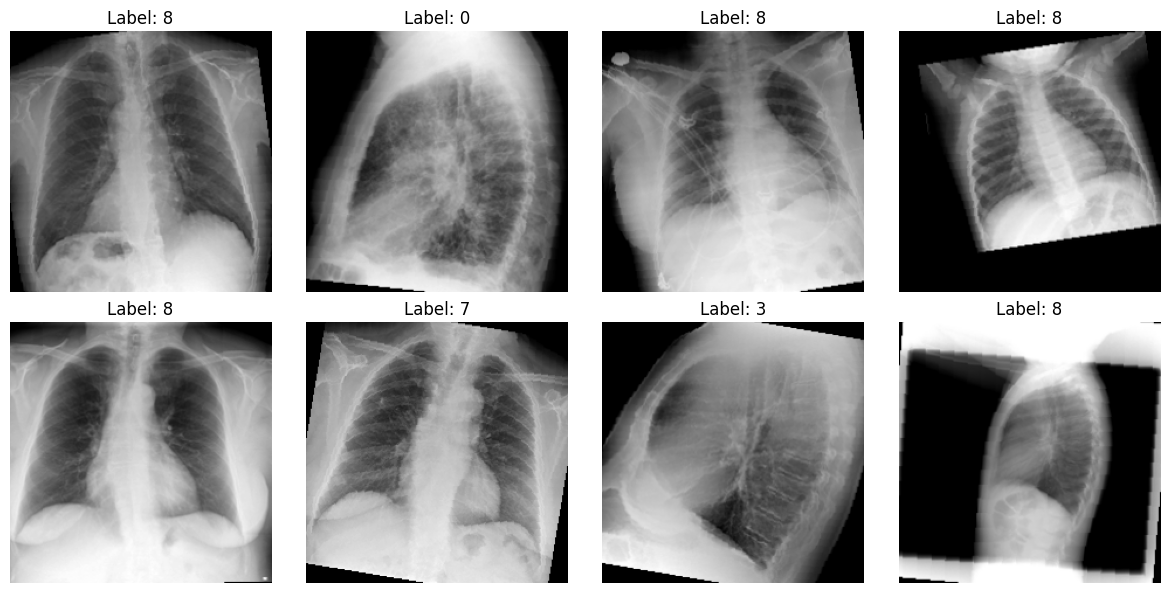

In [21]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

fig, axes = plt.subplots(2,4, figsize=(12,6))

for i, ax in enumerate(axes.flatten()):

    img = images[i].squeeze().numpy()

    ax.imshow(img, cmap='gray')

    ax.set_title(f"Label: {labels[i].item()}")

    ax.axis('off')

plt.tight_layout()
plt.show()


In [22]:
NUM_CLASSES = train_df['EncodedLabel'].nunique()

print("Number of classes :", NUM_CLASSES)

Number of classes : 14


In [20]:
import ast
from sklearn.preprocessing import LabelEncoder

# ============================================================
# CREATE LABEL COLUMN
# ============================================================

train_df['Label'] = train_df['FilteredLabels'].apply(
    lambda x: ast.literal_eval(x)[0]
)

val_df['Label'] = val_df['FilteredLabels'].apply(
    lambda x: ast.literal_eval(x)[0]
)

test_df['Label'] = test_df['FilteredLabels'].apply(
    lambda x: ast.literal_eval(x)[0]
)

# ============================================================
# LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()

train_df['EncodedLabel'] = label_encoder.fit_transform(
    train_df['Label']
)

val_df['EncodedLabel'] = label_encoder.transform(
    val_df['Label']
)

test_df['EncodedLabel'] = label_encoder.transform(
    test_df['Label']
)

print("Encoded labels created successfully")

print(train_df[['Label', 'EncodedLabel']].head())

Encoded labels created successfully
              Label  EncodedLabel
0            normal             8
1  alveolar pattern             0
2  pleural effusion             9
3  pleural effusion             9
4  alveolar pattern             0
